# 02 · FunnyBirds CBM — where does each concept answer come from?

We begin as a new reader who knows only the model's promise: an image `x` is encoded into 26 named internal values `z_j`; each `z_j` is used to predict a concept label `c_j`; all `z_j` values are used to predict species `y`.

For example, `z_tail_3(x)` should support the report `c_tail_3=1` when tail type 3 is visible. High ordinary-image concept accuracy does not tell us whether `z_tail_3` used the tail, the body, or both.

We will separate three questions:

1. **Correctness:** is the reported concept `c_pred_j` correct on an ordinary image?
2. **Grounding:** does changing part `j` causally change `z_j` in the expected direction?
3. **Stored leakage:** does `z_j` retain information beyond concept label `c_j`?

The intervention tests address grounding. A representation probe addresses stored leakage. Neither substitutes for the other.


In [1]:
import os, json, re, glob
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
CURATED = Path(os.environ["CURATED_DATA"]); CWD = Path.cwd(); REPO = CWD if (CWD/"analysis").is_dir() else CWD.parent
import sys; sys.path.insert(0, str(REPO/"analysis"))
try:
    from plotting import set_paper_style, PALETTE; set_paper_style()
    CBM_C, MCBM_C = PALETTE["CBM"], PALETTE["MCBM"]
except Exception:
    CBM_C, MCBM_C = "#0072B2", "#D55E00"
plt.rcParams["figure.dpi"]=120
EPS = 1e-3
def parse_stem(stem):
    m=re.match(r"^funnybirds-(vanilla|cbm|mcbm)(?:-g([0-9p]+))?-s(\d+)$", stem)
    if not m: return None
    gamma=float(m.group(2).replace("p",".")) if m.group(2) else np.nan
    return m.group(1), gamma, int(m.group(3))
def need(p, how):
    ok=Path(p).exists()
    if not ok: print(f"[pending] {p}\n  produce it:  {how}")
    return ok
# ---- seed-aware grounding loaders ----
def load_grounding(prefix):
    """All seeds for a config prefix -> one df with a 'seed' column (None if absent)."""
    fs = sorted(glob.glob(str(CURATED/"grounding"/f"{prefix}-s*.parquet")))
    if not fs: return None
    out=[]
    for f in fs:
        d=pd.read_parquet(f); d["seed"]=int(re.search(r"-s(\d+)\.parquet$", f).group(1)); out.append(d)
    return pd.concat(out, ignore_index=True)
def per_part_seedagg(df, visible_only=True):
    """per (seed,part) retained_frac -> per-part mean/std/count across seeds."""
    d = df[df["changed_frac"]>EPS] if (visible_only and "changed_frac" in df.columns) else df
    g = d.groupby(["seed","part"]).agg(pi=("p_intact","mean"), pr=("p_removed","mean"))
    g["rf"] = g.pr/g.pi
    return g["rf"].groupby("part").agg(["mean","std","count"])


## Reading the quantities

Each graph names its variable, because the scales mean different things.

| Variable | Meaning |
|---|---|
| `c_pred_j` | Predicted probability for concept `j`, from 0 to 1. |
| `z_j` | Raw internal score for concept slot `j`; not a probability. |
| `margin = z_donor,cf − z_source,cf` | After a swap, positive means the inserted concept beats the old concept. |
| `ordering_correct = 1[margin > 0]` | One when the replacement wins, otherwise zero. Its mean is the fraction of swaps won. |
| `retained_frac = p_removed / p_intact` | Fraction of the original concept probability left after deletion. |

CBM does not anchor raw `z_j` to a fixed scale, so values in the tens are allowed. Raw CBM and MCBM values must not be compared directly.


## 1 · Did training produce a usable CBM?

Before asking where a concept came from, verify that training worked.

We measure held-out species accuracy `P(y_pred=y)` and concept accuracy `P(c_pred=c)`. If either is poor, later failures might merely be failed optimization. If both are good, we may investigate grounding—but good accuracy alone cannot establish grounding.


,epoch,task,concept
0,5,0.6450,0.9615
1,50,0.7442,0.9933
2,100,0.7504,0.9944
3,150,0.7536,0.9960


SANITY CHECK: optimization reached high held-out accuracy. Overfitting cannot be judged from four accuracy checkpoints alone.


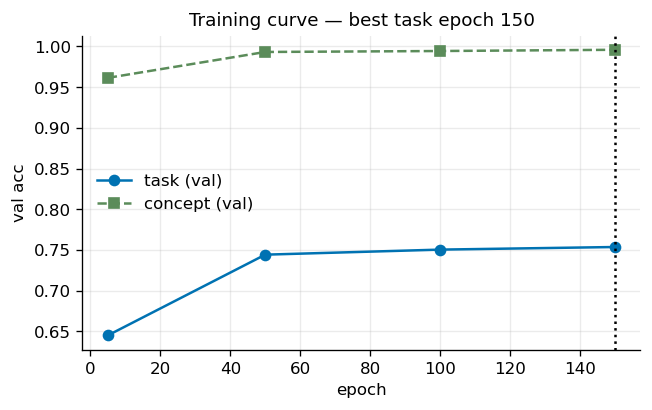

In [2]:
import torch
preds = REPO/"external"/"minimal_cbm"/"results"/"funnybirds-cbm"/"1"/"predictions"
def _acc(pth):
    d = torch.load(pth, map_location="cpu", weights_only=False)
    yp,y=d["y_preds"],d["y"]
    ta=(yp.argmax(-1)==y).float().mean().item() if yp.ndim>1 else (yp==y).float().mean().item()
    ca=None
    if d.get("c_preds") is not None and d.get("c") is not None:
        cp=d["c_preds"]; cp=cp[...,0] if cp.ndim==3 else cp; ca=((cp>=0.5).float()==d["c"]).float().mean().item()
    return ta,ca
fs=sorted(glob.glob(str(preds/"epoch_*.pth")), key=lambda p:int(re.findall(r"epoch_(\d+)",p)[0]))
if not fs: print(f"[pending] no per-epoch predictions in {preds}")
else:
    R=pd.DataFrame([(int(re.findall(r"epoch_(\d+)",f)[0]),*_acc(f)) for f in fs],
                   columns=["epoch","task","concept"]).sort_values("epoch"); best=int(R.loc[R.task.idxmax(),"epoch"])
    display(R.round(4)); fig,ax=plt.subplots(figsize=(6,3.4))
    ax.plot(R.epoch,R.task,"o-",color=CBM_C,label="task (val)")
    if R.concept.notna().any(): ax.plot(R.epoch,R.concept,"s--",color="#5B8C5A",label="concept (val)")
    ax.axvline(best,ls=":",color="k"); ax.set_xlabel("epoch"); ax.set_ylabel("val acc")
    ax.set_title(f"Training curve — best task epoch {best}"); ax.legend()
    print("SANITY CHECK: optimization reached high held-out accuracy. "
          "Overfitting cannot be judged from four accuracy checkpoints alone.")


**What appeared.** Concept accuracy is near 1.0 and species accuracy levels near 0.75. The model is usable for analysis. The sparse saved epochs do not establish absence of overfitting; that would require validation loss or denser checkpoints.

**Why continue.** The model answers ordinary labels well. We next check whether its individual positive and negative concept scores also look sensible before any intervention.


## 2 · Ordinary-image control

For each part, choose a source concept that is present and a donor alternative that is absent. On the untouched image `x_orig`, a working concept layer should satisfy

`z_source,orig > 0` and `z_donor,orig < 0`.

This control matters because a later swap is interpretable only if the same scores behave normally before the unusual part combination is introduced.


CBM swap source: /scratch/network/cr7998/cv_emergence_project/curated_data/swap_fixed_v2_attempt2/funnybirds-cbm-s1.csv


,z_src_present,z_donor_absent
part,,
tail,10.559,-20.968
wing,12.645,-19.943
beak,14.495,-13.543
foot,17.895,-15.718
eye,11.836,-16.511


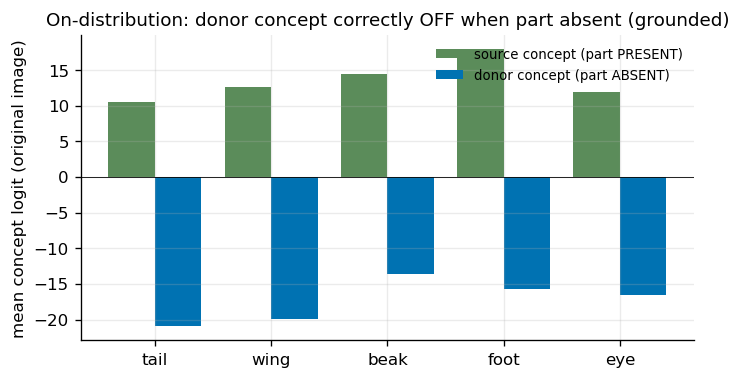

In [3]:
_swap_candidates = [
    CURATED/"swap_fixed_v2_attempt2"/"funnybirds-cbm-s1.csv",
    CURATED/"swap_fixed_v2"/"funnybirds-cbm-s1.csv",
    CURATED/"swap"/"funnybirds-cbm-s1.csv",
]
SW = next((p for p in _swap_candidates if p.exists()), _swap_candidates[0])
print("CBM swap source:", SW)
if "fixed_v2" not in str(SW):
    print("[PROVISIONAL] using legacy independently rendered swaps")
ORDER=["tail","wing","beak","foot","eye"]
if not need(SW, 'CONFIG_PREFIX=funnybirds-cbm GAMMAS="0" SEEDS="1" sbatch train/renderer_swap.slurm'):
    S=None
else:
    S=pd.read_csv(SW)
    g=S.groupby("part").agg(z_src_present=("z_old_orig","mean"),
                            z_donor_absent=("z_new_orig","mean")).reindex(ORDER)
    display(g.round(3))
    fig,ax=plt.subplots(figsize=(6.6,3.3)); x=np.arange(len(g)); w=0.4
    ax.bar(x-w/2,g.z_src_present,w,color="#5B8C5A",label="source concept (part PRESENT)")
    ax.bar(x+w/2,g.z_donor_absent,w,color=CBM_C,label="donor concept (part ABSENT)")
    ax.axhline(0,color="k",lw=0.5); ax.set_xticks(x); ax.set_xticklabels(g.index)
    ax.set_ylabel("mean concept logit (original image)"); ax.legend(fontsize=8)
    ax.set_title("On-distribution: donor concept correctly OFF when part absent (grounded)")

**What appeared.** Every part has a strongly positive `z_source,orig` and a strongly negative `z_donor,orig`. Thus the concept layer looks normal on the ordinary test distribution.

**Why continue.** Ordinary images preserve the training correlation between species and parts. We now remove one part to see whether its own concept actually depends on its pixels.


## 3 · Necessity test: remove one part

Let `p_intact` be the predicted probability of the canonical concept on the original image and `p_removed` the probability after deleting that part. We plot

`retained_frac = p_removed / p_intact`.

If the visible part is necessary for the answer, `retained_frac` should approach 0. If it remains high, evidence elsewhere in the image can sustain the concept.

Some nominal deletions change almost no pixels because the part was already hidden. Therefore we show both all removals and `visible_only`, where the part map confirms a real pixel change.


,retained_all,retained_visible,vis_std,conf_on_occluded,frac_noop
part,,,,,
tail,0.349,0.158,0.040,0.989,0.324
eye,0.050,0.035,0.009,0.851,0.020
beak,0.047,0.032,0.006,0.970,0.066
foot,0.025,0.025,0.016,NaN,0.000
wing,0.011,0.011,0.006,NaN,0.000


n_seeds = 3  (seeds: [1, 2, 3])


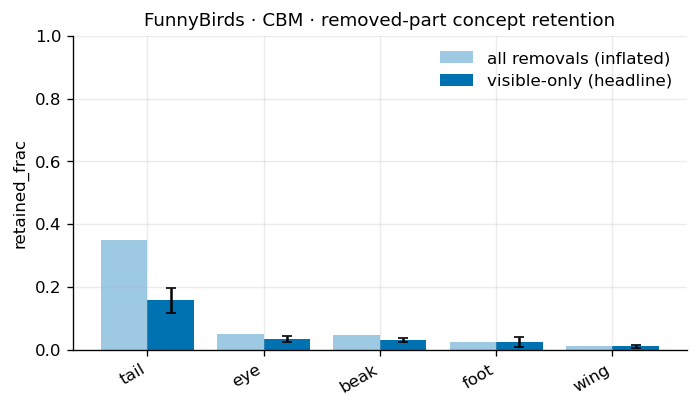

In [4]:
G = load_grounding("funnybirds-cbm")
if G is None: print("[pending] bash analysis/grounding_sweep.sh")
else:
    allp = per_part_seedagg(G, visible_only=False)
    visp = per_part_seedagg(G, visible_only=True)
    R = pd.DataFrame({"retained_all":allp["mean"], "retained_visible":visp["mean"],
                      "vis_std":visp["std"]})
    if "changed_frac" in G.columns:
        occ = G[G["changed_frac"]<=EPS]
        R["conf_on_occluded"] = occ.groupby("part").p_intact.mean()
        R["frac_noop"] = G.groupby("part").changed_frac.apply(lambda s:(s<=EPS).mean())
    R = R.sort_values("retained_visible", ascending=False); display(R.round(3))
    print(f"n_seeds = {G.seed.nunique()}  (seeds: {sorted(G.seed.unique())})")
    fig,ax=plt.subplots(figsize=(6.6,3.4)); x=np.arange(len(R)); w=0.4
    ax.bar(x-w/2, R.retained_all, w, color="#9ec9e2", label="all removals (inflated)")
    ax.bar(x+w/2, R.retained_visible, w, yerr=R.vis_std.fillna(0), capsize=3, color=CBM_C, label="visible-only (headline)")
    ax.set_xticks(x); ax.set_xticklabels(R.index, rotation=30, ha="right")
    ax.set_ylabel("retained_frac"); ax.set_ylim(0,1); ax.legend()
    ax.set_title("FunnyBirds · CBM · removed-part concept retention")

**What appeared.** Visible-tail deletion leaves `retained_frac≈0.16`; other parts are near 0. The tail therefore responds strongly to deletion—it loses about 84% of its probability—but retains more support from elsewhere than the other parts.

This is not yet proof of species lookup. Deletion creates an unnatural absent-part image and does not reveal which alternative tail the model would choose. A valid replacement is the stronger next test.


## 4 · Construct a one-part counterfactual

Create `x_cf` by keeping the source image's camera, background, lighting, and all other parts fixed while replacing one named part with a valid donor variant.

Before interpreting model scores, verify the intervention itself. If multiple regions change, then a change in `z_j` cannot be attributed to the named part.


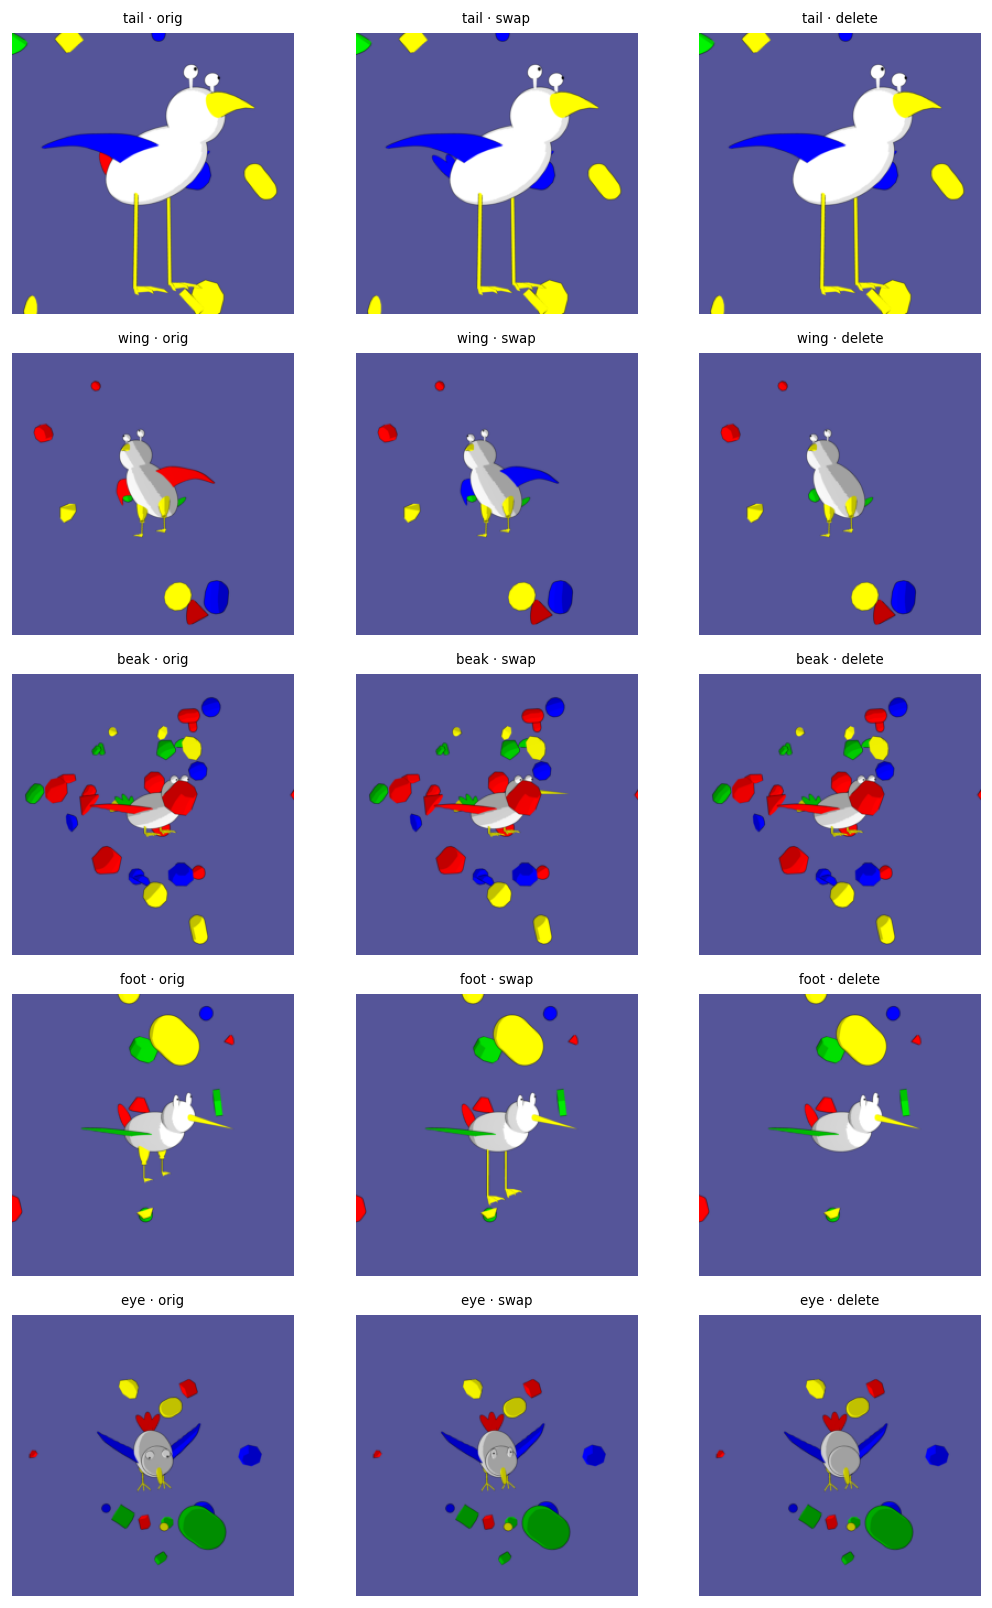

In [5]:
import matplotlib.image as mpimg
exdir=CURATED/"swap"/"examples"; tags=["orig","swap","delete"]
if exdir.exists() and any(exdir.glob("*.png")):
    fig,axes=plt.subplots(len(ORDER),len(tags),figsize=(3*len(tags),2.7*len(ORDER)))
    for r,part in enumerate(ORDER):
        for c,t in enumerate(tags):
            axm=axes[r,c] if len(ORDER)>1 else axes[c]
            fs=sorted(exdir.glob(f"{part}_*_{t}.png"))
            if fs: axm.imshow(mpimg.imread(str(fs[0])))
            axm.set_title(f"{part} · {t}",fontsize=8); axm.axis("off")
    plt.tight_layout()
else:
    need(exdir/"<part>_*_orig.png", 'run train/renderer_swap.slurm (it saves examples first)')

**What appeared.** The displayed original/swap/deletion triplets look plausible. This is only a human spot check, so the next plot marks every changed pixel.


### 4a · Pixel-difference validity check

For each displayed pair, compute `D(u,v)=1[x_orig(u,v) != x_cf(u,v)]`. A valid one-part intervention should produce one compact changed region at the named part. Scattered changes elsewhere would invalidate the causal interpretation.


,changed_pixels,image_fraction
part,,
tail,349,0.005325
wing,827,0.012619
beak,111,0.001694
foot,734,0.011200
eye,177,0.002701


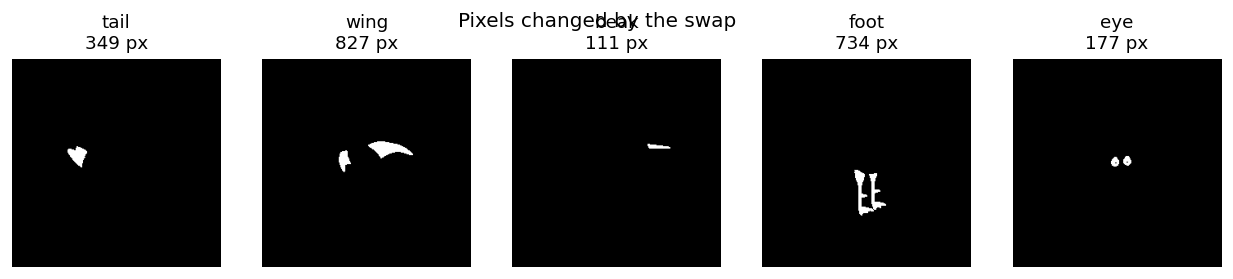

In [6]:
if exdir.exists():
    rows=[]; fig,axes=plt.subplots(1,len(ORDER),figsize=(2.6*len(ORDER),2.6))
    for axm,part in zip(axes,ORDER):
        origs=sorted(exdir.glob(f"{part}_*_orig.png"))
        if not origs: axm.axis("off"); continue
        po=origs[0]; ps=Path(str(po).replace("_orig.png","_swap.png"))
        if not ps.exists(): axm.axis("off"); continue
        a=mpimg.imread(str(po))[...,:3]; b=mpimg.imread(str(ps))[...,:3]
        diff=np.max(np.abs(a-b),axis=-1)>1e-3
        ys,xs=np.where(diff); frac=float(diff.mean())
        rows.append({"part":part,"changed_pixels":int(diff.sum()),"image_fraction":frac})
        axm.imshow(diff,cmap="gray",vmin=0,vmax=1); axm.set_title(f"{part}\n{diff.sum()} px"); axm.axis("off")
    display(pd.DataFrame(rows).set_index("part")); fig.suptitle("Pixels changed by the swap"); plt.show()
else: print("[pending] rendered examples")


**What appeared.** The saved examples show compact changes at tail, wing, beak, foot, and eye. The examples support proceeding, although a final production run should save this check for every swap rather than only examples.


### 4b · Does the concept answer follow the replacement?

After the swap, compare only the two relevant raw scores:

`margin = z_donor,cf − z_source,cf`.

`margin>0` means the visible replacement concept wins. `margin<0` means the old/source concept still wins. The plotted fraction is

`mean(ordering_correct) = P(margin>0)`.

Both forward and backward directions are shown. Agreement between them checks that source and donor were not accidentally reversed in the analysis.


direction,bwd,fwd
part,,
tail,0.298,0.312
wing,0.852,0.880
beak,0.520,0.400
foot,0.916,0.906
eye,0.518,0.486


Near 1 = replacement usually wins. Lower values are swap-following failures; the cause is tested below.


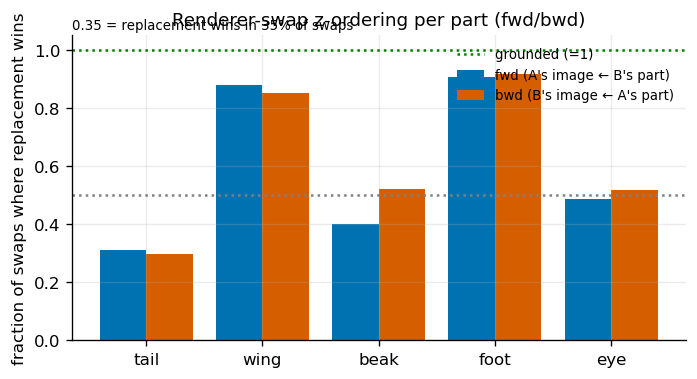

In [7]:
if S is not None:
    ordf=S.groupby(["part","direction"]).ordering_correct.mean().unstack().reindex(ORDER)
    display(ordf.round(3))
    fig,ax=plt.subplots(figsize=(6.6,3.3)); x=np.arange(len(ordf)); w=0.4
    ax.bar(x-w/2,ordf.get("fwd"),w,color=CBM_C,label="fwd (A's image ← B's part)")
    ax.bar(x+w/2,ordf.get("bwd"),w,color="#D55E00",label="bwd (B's image ← A's part)")
    ax.axhline(1.0,ls=":",color="green",label="grounded (=1)"); ax.axhline(0.5,ls=":",color="gray")
    ax.set_xticks(x); ax.set_xticklabels(ordf.index); ax.set_ylim(0,1.05)
    ax.set_ylabel("fraction of swaps where replacement wins")
    ax.text(0,1.02,"0.35 = replacement wins in 35% of swaps",transform=ax.transAxes,fontsize=8); ax.legend(fontsize=8)
    ax.set_title("Renderer-swap z-ordering per part (fwd/bwd)")
    print("Near 1 = replacement usually wins. Lower values are swap-following failures; the cause is tested below.")
else: print("[pending] swap CSV")


**What appeared.** Wing and foot usually follow the replacement. Tail usually does not; beak is near a tie and eye is mixed. Both directions agree.

At this stage the result is a **part-specific grounding failure**: visible pixels and the reported concept disagree. It is too early to name species backwash as the cause, because visibility and variant difficulty remain alternatives.


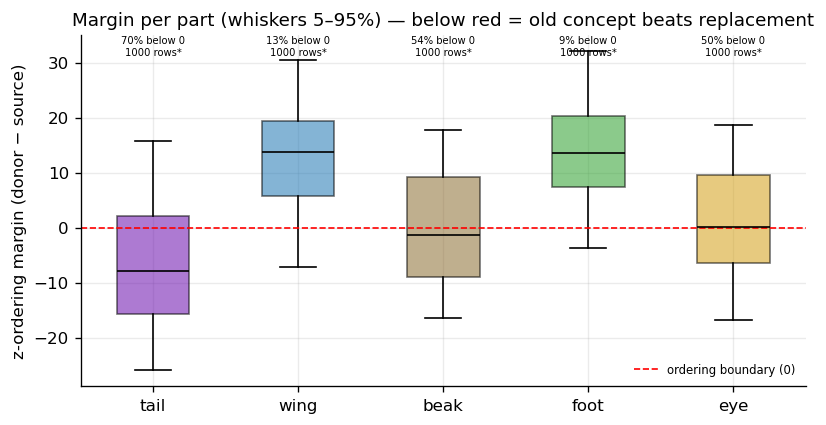

In [8]:
if S is not None:
    PCOL={"tail":"#6a0dad","wing":"#1f77b4","beak":"#8c6d31","foot":"#2ca02c","eye":"#d4a017"}
    order=[p for p in ORDER if (S.part==p).any()]
    data=[S[S.part==p].margin.values for p in order]
    fig,ax=plt.subplots(figsize=(7.8,3.8))
    bp=ax.boxplot(data,showfliers=False,patch_artist=True,medianprops=dict(color="k"),whis=(5,95))
    for patch,p in zip(bp["boxes"],order): patch.set_facecolor(PCOL.get(p,"#888")); patch.set_alpha(0.55)
    ax.axhline(0,color="r",lw=1,ls="--",label="ordering boundary (0)")
    ax.set_xticks(range(1,len(order)+1)); ax.set_xticklabels(order)
    y0,y1=ax.get_ylim()
    for i,p in enumerate(order):
        mp=S[S.part==p].margin
        ax.annotate(f"{100*(mp<=0).mean():.0f}% below 0\n{len(mp)} rows*",(i+1,y1),fontsize=6,ha="center",va="top")
    ax.set_ylabel("z-ordering margin (donor − source)"); ax.legend(fontsize=7)
    ax.set_title("Margin per part (whiskers 5–95%) — below red = old concept beats replacement")
else: print("[pending] swap CSV")


The margin distributions show that the means are not created by a few extreme swaps. Tail margins are mostly below 0; wing and foot margins are mostly above 0.

Rows reuse original images, so plotted rows are not independent samples. We next verify coverage before making comparisons among parts or variants.


### 4c · Coverage and integrity

Print row counts, missing values, directions, source species, donor species, and variants. This test is inserted to rule out a simple sampling explanation such as “tail used only five species” or “one direction is missing.”

The present CSV does not store a unique original-image ID. Consequently uncertainty must be grouped by seed or species, not calculated as if every row were independent.


In [9]:
if S is not None:
    required=["sid_src","sid_donor","part","var_src","var_donor","z_new","z_old",
              "z_new_orig","z_old_orig","margin","ordering_correct","direction"]
    print("rows:",len(S),"  missing required columns:",[c for c in required if c not in S])
    present=[c for c in required if c in S]
    print("missing values in required fields:",int(S[present].isna().sum().sum()))
    coverage=(S.groupby(["part","direction"])
                .agg(rows=("margin","size"),source_species=("sid_src","nunique"),
                     donor_species=("sid_donor","nunique"),source_variants=("var_src","nunique"),
                     donor_variants=("var_donor","nunique")))
    display(coverage)
    print("Important limitation: the current CSV does not store an original-image ID. "
          "Rows reuse originals, so uncertainty must be grouped by seed/species, not by row.")


rows: 5000   missing required columns: []
missing values in required fields: 0


rows  source_species  donor_species  source_variants  \
part direction                                                         
beak bwd         500              35             40                4   
     fwd         500              40             35                4   
eye  bwd         500              39             38                3   
     fwd         500              38             39                3   
foot bwd         500              38             38                4   
     fwd         500              38             38                4   
tail bwd         500              38             37                9   
     fwd         500              37             38                9   
wing bwd         500              39             36                6   
     fwd         500              36             39                6   

                donor_variants  
part direction                  
beak bwd                     4  
     fwd                     4  
eye  bwd                     3  
     fwd                     3  
foot bwd                     4  
     fwd                     4  
tail bwd                     9  
     fwd                     9  
wing bwd                     6  
     fwd                     6

Important limitation: the current CSV does not store an original-image ID. Rows reuse originals, so uncertainty must be grouped by seed/species, not by row.


### 4d · Did the inserted pixels move their own concept at all?

Ordering mixes two effects: the donor may rise and the source may remain high. Isolate donor movement with

`donor_shift = z_donor,cf − z_donor,orig`.

Positive `donor_shift` means the inserted pixels affected their named concept, even if `margin` remains negative. This distinguishes “the donor did not respond” from “the donor responded but could not overcome the old answer.”


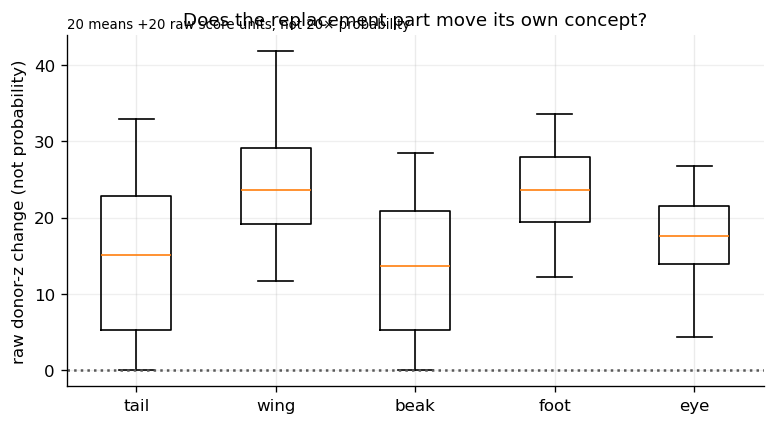

,mean,median,std,size
part,,,,
beak,13.699,13.694,9.350,1000
eye,17.267,17.652,6.372,1000
foot,23.365,23.583,6.651,1000
tail,14.884,15.071,10.789,1000
wing,24.799,23.605,9.314,1000


In [10]:
if S is not None and {"z_new","z_new_orig"}.issubset(S.columns):
    d=S.assign(donor_shift=S.z_new-S.z_new_orig)
    order=[p for p in ORDER if (d.part==p).any()]
    vals=[d.loc[d.part==p,"donor_shift"].values for p in order]
    fig,ax=plt.subplots(figsize=(7.5,3.8))
    ax.boxplot(vals,tick_labels=order,showfliers=False,whis=(5,95))
    ax.axhline(0,color="0.35",ls=":")
    ax.set_ylabel("raw donor-z change (not probability)")
    ax.text(0,1.02,"20 means +20 raw score units, not 20× probability",transform=ax.transAxes,fontsize=8)
    ax.set_title("Does the replacement part move its own concept?")
    ax.grid(axis="y",alpha=.2); plt.show()
    display(d.groupby("part").donor_shift.agg(["mean","median","std","size"]).round(3))


**What appeared.** Donor scores usually rise, including for tail. Thus the model is not simply blind to replacement tails. A common tail failure is that `z_donor` moves upward but `z_source` remains even larger.

**Why continue.** A small or hidden replacement can naturally produce a weak donor shift. We must control visibility before attributing the remaining old-answer advantage to the body or species.


## 5 · Visibility alternative

Let `pixel_count_cf` be the number of visible pixels belonging to the inserted part. Bin swaps by this count and plot

`P(margin>0 | visibility bin)`.

If small or occluded parts fully explain failure, tail should approach wing/foot performance in high-visibility bins. If tail improves but remains lower, test-time visibility is only a partial explanation. Every bin shows `n` because a rate based on a few swaps is unstable.


fraction_correct    n
part vis_bin                         
beak 0–20                  0.268  123
     20–50                 0.299  164
     50–100                0.464  192
     100–200               0.498  237
     200–500               0.617  227
     500–10000             0.544   57
eye  0–20                  0.296  115
     20–50                 0.451  335
     50–100                0.548  299
     100–200               0.571  203
     200–500               0.771   48
     500–10000               NaN    0
foot 0–20                  0.652   46
     20–50                 0.807  109
     50–100                0.915  211
     100–200               0.950  339
     200–500               0.946  278
     500–10000             0.882   17
tail 0–20                  0.163  386
     20–50                 0.277  130
     50–100                0.234   94
     100–200               0.497  187
     200–500               0.417  180
     500–10000             0.696   23
wing 0–20                  0.848  132
     20–50                 0.778   18
     50–100                0.786   56
     100–200               0.790  119
     200–500               0.865  349
     500–10000             0.920  326

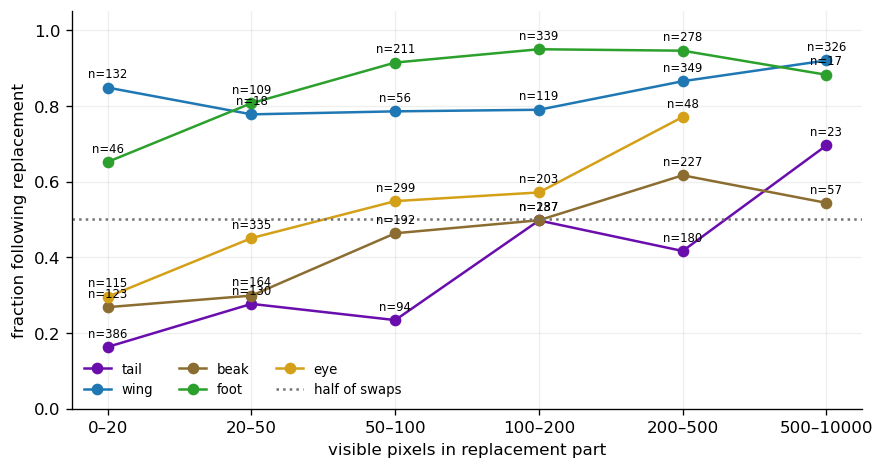

In [11]:
if S is not None and "pixel_count_cf" in S.columns:
    PCOL={"tail":"#6a0dad","wing":"#1f77b4","beak":"#8c6d31","foot":"#2ca02c","eye":"#d4a017"}
    bins=[0,20,50,100,200,500,10000]
    labels=[f"{bins[i]}–{bins[i+1]}" for i in range(len(bins)-1)]
    d=S.copy()
    d["vis_bin"]=pd.cut(d.pixel_count_cf,bins=bins,labels=labels,right=False)
    tab=d.groupby(["part","vis_bin"],observed=False).ordering_correct.agg(["mean","size"])
    display(tab.rename(columns={"mean":"fraction_correct","size":"n"}).round(3))
    fig,ax=plt.subplots(figsize=(8.5,4.3))
    for p in ORDER:
        q=tab.loc[p]
        ax.plot(range(len(labels)),q["mean"],"o-",label=p,color=PCOL[p])
        for x,(y,n) in enumerate(zip(q["mean"],q["size"])):
            if pd.notna(y): ax.annotate(f"n={int(n)}",(x,y),xytext=(0,6),textcoords="offset points",ha="center",fontsize=7)
    ax.axhline(.5,color="0.45",ls=":",label="half of swaps")
    ax.set(xticks=range(len(labels)),xticklabels=labels,ylim=(0,1.05),
           xlabel="visible pixels in replacement part",ylabel="fraction following replacement")
    ax.legend(ncol=3,fontsize=8); ax.grid(alpha=.2); plt.show()


Read each point together with its `n`. A rising tail curve supports a visibility effect. Persistent negative margins among large visible tails reject visibility as the only cause. Bin composition may also change with tail variant, so a non-monotonic wiggle is not itself a mechanism.


,all_swaps,visible_only(>=50px)
part,,
tail,0.305,0.426
wing,0.866,0.871
beak,0.460,0.530
foot,0.911,0.938
eye,0.502,0.576


Improvement after filtering means visibility contributes. A remaining gap needs further explanation.


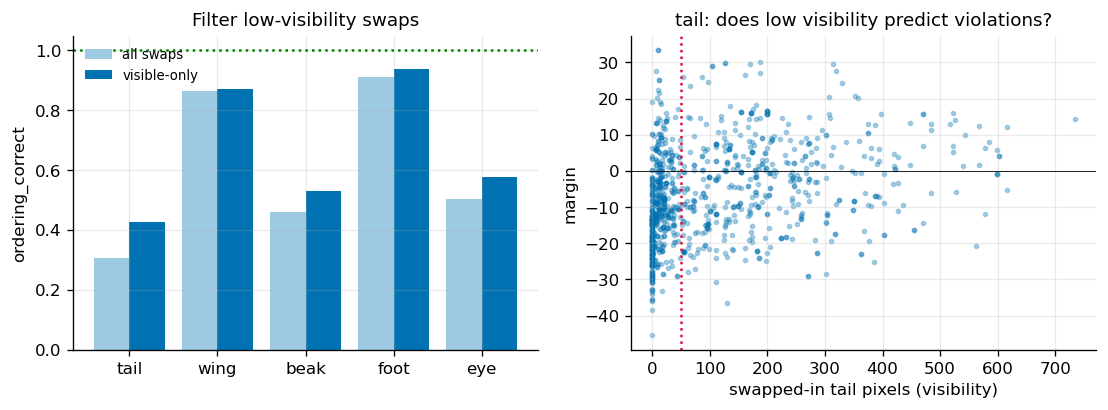

In [12]:
if S is not None and "pixel_count_cf" in S.columns:
    MIN_PX=50
    before=S.groupby("part").ordering_correct.mean()
    after =S[S.pixel_count_cf>=MIN_PX].groupby("part").ordering_correct.mean()
    C=pd.DataFrame({"all_swaps":before,f"visible_only(>={MIN_PX}px)":after}).reindex(ORDER)
    display(C.round(3))
    fig,ax=plt.subplots(1,2,figsize=(11,3.4)); x=np.arange(len(C)); w=0.4
    ax[0].bar(x-w/2,C.iloc[:,0],w,color="#9ec9e2",label="all swaps")
    ax[0].bar(x+w/2,C.iloc[:,1],w,color=CBM_C,label="visible-only")
    ax[0].axhline(1,ls=":",color="green"); ax[0].set_xticks(x); ax[0].set_xticklabels(C.index)
    ax[0].set_ylim(0,1.05); ax[0].set_ylabel("ordering_correct"); ax[0].legend(fontsize=8)
    ax[0].set_title("Filter low-visibility swaps")
    t=S[S.part=="tail"]
    ax[1].scatter(t.pixel_count_cf,t.margin,s=6,alpha=0.3,color=CBM_C)
    ax[1].axhline(0,color="k",lw=0.5); ax[1].axvline(MIN_PX,ls=":",color="crimson")
    ax[1].set_xlabel("swapped-in tail pixels (visibility)"); ax[1].set_ylabel("margin")
    ax[1].set_title("tail: does low visibility predict violations?")
    print("Improvement after filtering means visibility contributes. A remaining gap needs further explanation.")
elif S is not None:
    print("[pending] swap CSV lacks pixel_count_cf (run WITHOUT --no-v2)")


**What appeared.** Removing swaps below 50 visible pixels raises tail replacement wins from about 0.37 to 0.48, but tail remains far below wing and foot. Test-time visibility explains part, not all, of the gap.

This does not yet test the training-time hypothesis: a non-placeholder tail can have almost no visible pixels while its parameter-derived concept label remains positive, which may teach the encoder to use the body. Placeholder/removed parts already receive an all-zero group in the standard data. We next examine whether particular tail shapes explain the residual.


## 6 · Variant-difficulty alternative

For each tail swap, let `var_donor` be the visible replacement variant and let `argmax_tail` be the tail concept with the largest score. Plot

`P(argmax_tail = var_donor | var_src, var_donor)`.

A grounded recognizer produces a bright diagonal. Off-diagonal columns indicate that several visible replacements collapse onto one default answer. This test is inserted because visually similar or rare tail variants could imitate body-based backwash.


per-part diagonal (fraction correctly attributed): {'tail': 0.272, 'wing': 0.807, 'beak': 0.448, 'foot': 0.905, 'eye': 0.501}


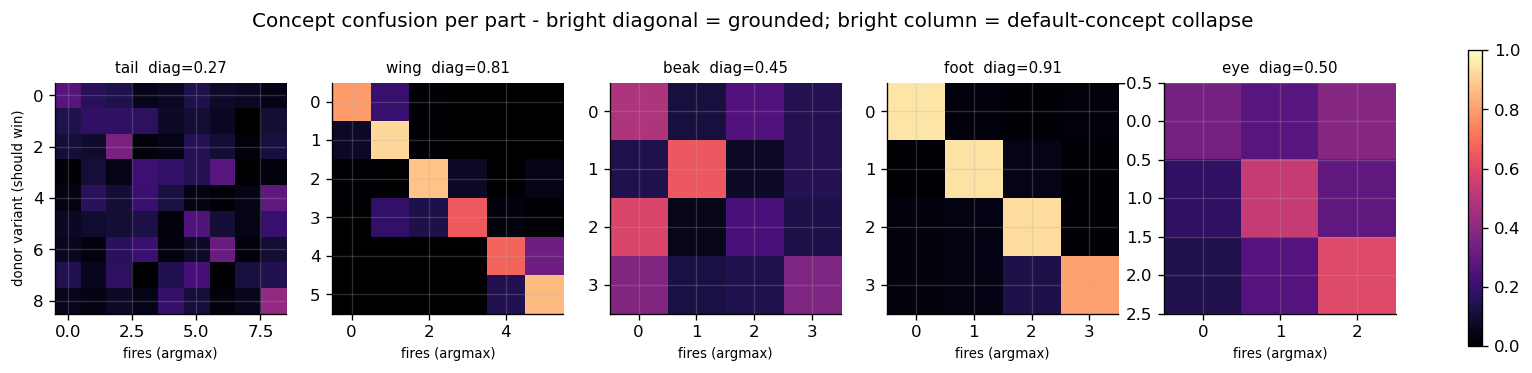

In [13]:
if S is not None:
    # ALL-PART confusion: for each part, which variant's concept fires strongest after a swap.
    # Bright diagonal = grounded (swapped-in variant wins); bright COLUMN = "default concept"
    # collapse. A grounded part (foot) should show a clean diagonal that contrasts the tail.
    have=[p for p in ORDER if any(c.startswith(f"z_cf_{p}_") for c in S.columns)]
    if not have:
        print("[pending] swap CSV has no z_cf_<part>_* columns.")
        print("  re-run with the current driver (logs all parts):")
        print("  CONFIG_PREFIX=funnybirds-cbm SEEDS=1 sbatch train/renderer_swap.slurm")
    else:
        fig,axes=plt.subplots(1,len(have),figsize=(3.1*len(have),3.2))
        if len(have)==1: axes=[axes]
        last=None; diags={}
        for ax,p in zip(axes,have):
            cols=sorted([c for c in S.columns if c.startswith(f"z_cf_{p}_")],
                        key=lambda c:int(c.split("_")[-1]))
            dd=S[S.part==p].dropna(subset=cols)
            if not len(dd): ax.set_title(f"{p} (no data)"); ax.axis("off"); continue
            n=len(cols); predv=dd[cols].values.argmax(1); dv=dd.var_donor.astype(int).values
            M=np.zeros((n,n))
            for a,b in zip(dv,predv):
                if 0<=a<n: M[a,b]+=1
            M=M/M.sum(1,keepdims=True).clip(min=1)
            diags[p]=round(float((predv==dv).mean()),3)
            last=ax.imshow(M,cmap="magma",vmin=0,vmax=1)
            ax.set_title(f"{p}  diag={diags[p]:.2f}",fontsize=9); ax.set_xlabel("fires (argmax)",fontsize=8)
        axes[0].set_ylabel("donor variant (should win)",fontsize=8)
        fig.suptitle("Concept confusion per part - bright diagonal = grounded; bright column = default-concept collapse")
        if last is not None: fig.colorbar(last,ax=axes,fraction=0.02)
        print("per-part diagonal (fraction correctly attributed):", diags)
else: print("[pending] swap CSV")

**What appeared.** Tail has a weak diagonal (`≈0.27`) and several replacements collapse toward recurring answers. Wing and foot succeeding in the same pipeline rule out a globally broken renderer or scorer.

This still does not distinguish visual similarity, frequency, visibility, and body influence. A tail-variant image atlas should be placed beside this matrix before making a visual-similarity claim.


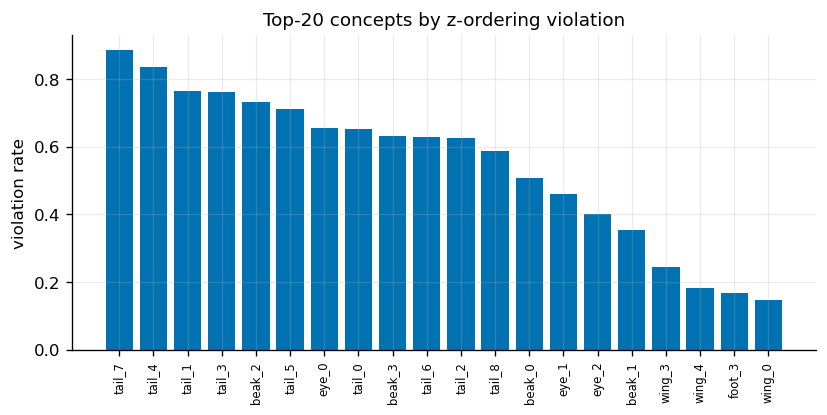

In [14]:
if S is not None:
    vc=S.assign(viol=~S.ordering_correct.astype(bool)).groupby(["part","var_donor"]).viol.mean().sort_values(ascending=False).head(20)
    fig,ax=plt.subplots(figsize=(8,3.4)); ax.bar([f"{p}_{int(v)}" for p,v in vc.index],vc.values,color=CBM_C)
    ax.set_ylabel("violation rate"); ax.set_title("Top-20 concepts by z-ordering violation"); plt.xticks(rotation=90,fontsize=7)
else: print("[pending] swap CSV")

The worst individual slots are mostly tails, with some beaks and eyes. Therefore the result is not caused by one corrupted tail index. We next separate source-tail variant from source species.


## 7 · Source variant before source species

Every species has a fixed canonical tail variant. Therefore a raw per-species failure graph can secretly be a tail-variant graph.

First estimate

`P(margin>0 | var_src, var_donor)`

with counts and visibility. Only after accounting for this structure is it meaningful to ask whether the unchanged species/body adds explanatory power.


,var_src,var_donor,follow,n,pixels
0,0,1,0.0,5,146.60
1,0,2,0.0,10,59.60
2,0,3,1.0,5,342.60
3,0,4,0.2,5,137.00
4,0,5,0.5,20,65.25
...,...,...,...,...,...
61,8,3,0.6,10,186.10
62,8,4,0.1,50,106.26
63,8,5,0.2,40,72.65
64,8,6,0.0,5,97.20


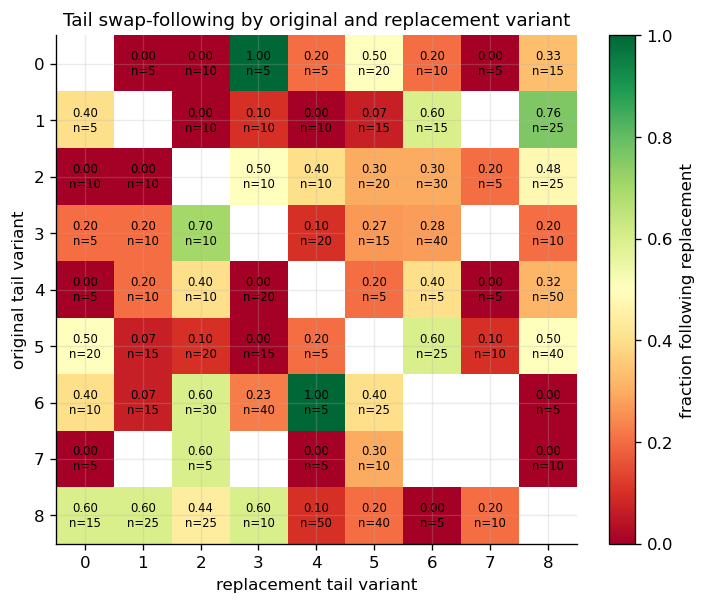

,var_src,sid_src,follow,n,pixels
0,0,7,0.167,30,12.300
2,0,28,0.200,20,141.050
3,0,42,0.267,15,142.200
1,0,8,1.000,10,268.000
4,1,4,0.160,25,57.040
5,1,20,0.267,15,26.000
8,1,46,0.333,15,167.400
6,1,22,0.360,25,35.120
7,1,29,1.000,10,50.400
15,2,43,0.000,10,34.300


In [15]:
if S is not None and "var_src" in S and "var_donor" in S:
    t=S[S.part=="tail"].copy()
    agg=t.groupby(["var_src","var_donor"]).agg(
        follow=("ordering_correct","mean"), n=("ordering_correct","size"),
        pixels=("pixel_count_cf","mean") if "pixel_count_cf" in t else ("margin","size")
    ).reset_index()
    H=agg.pivot(index="var_src",columns="var_donor",values="follow")
    N=agg.pivot(index="var_src",columns="var_donor",values="n")
    display(agg.round(2))
    fig,ax=plt.subplots(figsize=(7,5.5)); im=ax.imshow(H.values,cmap="RdYlGn",vmin=0,vmax=1,aspect="auto")
    ax.set(xticks=range(len(H.columns)),xticklabels=H.columns,
           yticks=range(len(H.index)),yticklabels=H.index,
           xlabel="replacement tail variant",ylabel="original tail variant")
    for r in range(H.shape[0]):
        for k in range(H.shape[1]):
            if pd.notna(H.iloc[r,k]): ax.text(k,r,f"{H.iloc[r,k]:.2f}\nn={int(N.iloc[r,k])}",ha="center",va="center",fontsize=7)
    ax.set_title("Tail swap-following by original and replacement variant")
    plt.colorbar(im,ax=ax,label="fraction following replacement"); plt.show()
    by_src=t.groupby(["var_src","sid_src"]).agg(follow=("ordering_correct","mean"),n=("ordering_correct","size"),pixels=("pixel_count_cf","mean")).reset_index()
    display(by_src.sort_values(["var_src","follow"]).round(3))
else: print("[pending] tail swap rows with variants")


**What appeared.** Some source–donor variant pairs work well and others fail. Variant combination clearly matters. Species comparisons must therefore be made within matched source variant, donor variant, direction, visibility range, and seed.


## 8 · Does the unchanged body/species still matter?

The raw display groups tail failures by `sid_src`, the source species whose body remains visible. Large differences are consistent with body influence, but are confounded by `var_src`, `var_donor`, visibility, and repeated images.

The stronger future test is factorial: hold the exact tail fixed while changing only the body/species. A causal body effect exists if

`z_tail(tail fixed, body B) − z_tail(tail fixed, body A) != 0`.

That test directly detects the proposed OR-over-species computation. The present bars are only a prompt for that controlled experiment.


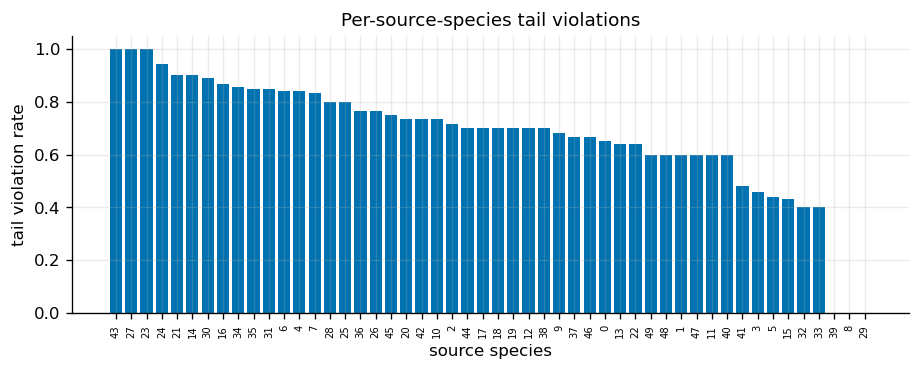

In [16]:
if S is not None:
    d=S[S.part=="tail"].assign(viol=~S[S.part=="tail"].ordering_correct.astype(bool))
    sv=d.groupby("sid_src").viol.mean().sort_values(ascending=False)
    fig,ax=plt.subplots(figsize=(9,3)); ax.bar(sv.index.astype(str),sv.values,color=CBM_C)
    ax.set_xlabel("source species"); ax.set_ylabel("tail violation rate"); ax.set_title("Per-source-species tail violations")
    plt.xticks(rotation=90,fontsize=6)
else: print("[pending] swap CSV")

**What appeared.** Raw failure rates vary greatly by source species. This is compatible with reliance on the unchanged body but does not uniquely prove it. We should not promote these unadjusted bars to the main causal claim.


n_seeds=3 | chance=0.020 | species<-z 0.986 | species<-c_preds 0.987


,species_code,n_variants
tail,0.193,9
wing,0.119,6
beak,0.082,4
foot,0.081,4
eye,0.061,3


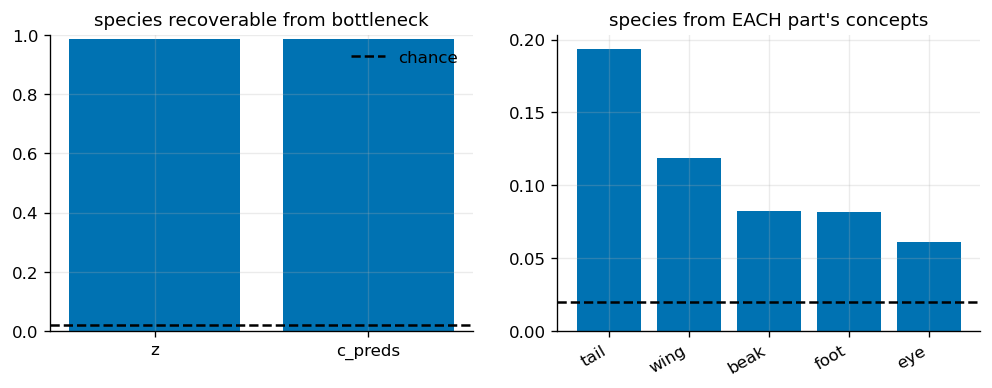

In [17]:
sps = sorted(glob.glob(str(CURATED/"species_probe"/"funnybirds-cbm-s*.json")))
PARTV=None
if not sps: print("[pending] bash analysis/grounding_sweep.sh")
else:
    Ss=[json.loads(Path(p).read_text()) for p in sps]; ch=Ss[0]["chance"]
    zc=np.mean([s["species_from_z"]["acc"] for s in Ss]); cc=np.mean([s["species_from_cpreds"]["acc"] for s in Ss])
    print(f"n_seeds={len(Ss)} | chance={ch:.3f} | species<-z {zc:.3f} | species<-c_preds {cc:.3f}")
    parts=list(Ss[0]["species_from_part_cpreds"].keys())
    PARTV=pd.DataFrame({"species_code":[np.mean([s["species_from_part_cpreds"][p]["acc"] for s in Ss]) for p in parts],
                        "n_variants":[Ss[0]["species_from_part_cpreds"][p]["n_variants"] for p in parts]}, index=parts)
    PARTV=PARTV.sort_values("species_code", ascending=False); display(PARTV.round(3))
    fig,ax=plt.subplots(1,2,figsize=(10,3.2))
    ax[0].bar(["z","c_preds"],[zc,cc],color=CBM_C); ax[0].axhline(ch,ls="--",color="k",label="chance")
    ax[0].set_ylim(0,1); ax[0].set_title("species recoverable from bottleneck"); ax[0].legend()
    ax[1].bar(PARTV.index, PARTV.species_code, color=CBM_C); ax[1].axhline(ch,ls="--",color="k")
    ax[1].set_title("species from EACH part's concepts"); plt.setp(ax[1].get_xticklabels(),rotation=30,ha="right")

## 9 · Stored species information is a different question

The probe predicts species `y` from either all bottleneck values `z`, all reported concepts `c_preds`, or one part's concept block.

Random species chance is `1/50=0.02`. But a tail-only probe already knows one of nine canonical tail variants, giving an approximate balanced-label baseline `9/50=0.18`; corresponding baselines are wing `6/50`, beak `4/50`, foot `4/50`, and eye `3/50`.

The observed single-part accuracies nearly equal those label-only baselines. Thus this graph does not demonstrate much extra species information inside one reported part block. A proper stored-leakage test compares `species←Z_part` with `species←C_part,true` within the same true variant.

Even zero stored leakage would not prove grounding: the encoder could recognize any species associated with tail type 3 and output the same `z_tail_3`. Only a controlled pixel intervention identifies that input route.


## 10 · Does the tail-concept change influence the species head?

Plot donor-species probability against

`margin = z_donor,cf − z_source,cf`.

This measures whether stronger donor-tail evidence influences the task head. It is **not a direct harm metric**: replacing one tail does not turn the whole source bird into the donor species, so low donor-species probability may be correct. The relevant explanatory failure was already established at the concept layer.


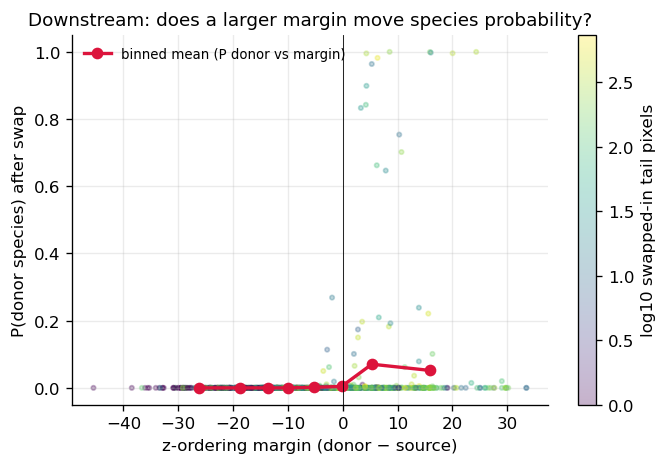

In [18]:
if S is not None:
    t=S[S.part=="tail"].copy()
    fig,ax=plt.subplots(figsize=(6.4,4))
    # colour by an INDEPENDENT variable (visibility), NOT by the margin's own sign (that
    # would be tautological). The relationship we care about is the binned-mean trend.
    if "pixel_count_cf" in t.columns:
        sc=ax.scatter(t.margin,t.p_cf_donor,s=7,alpha=0.3,
                      c=np.log10(t.pixel_count_cf.clip(lower=1)),cmap="viridis")
        fig.colorbar(sc,label="log10 swapped-in tail pixels")
    else:
        ax.scatter(t.margin,t.p_cf_donor,s=7,alpha=0.3,color="#888")
    t["mb"]=pd.qcut(t.margin,8,duplicates="drop")
    gb=t.groupby("mb",observed=True).agg(mx=("margin","mean"),my=("p_cf_donor","mean"))
    ax.plot(gb.mx,gb.my,"o-",color="crimson",lw=2,label="binned mean (P donor vs margin)")
    ax.axvline(0,color="k",lw=0.5); ax.set_xlabel("z-ordering margin (donor − source)")
    ax.set_ylabel("P(donor species) after swap"); ax.legend(fontsize=8)
    ax.set_title("Downstream: does a larger margin move species probability?")
else: print("[pending] swap CSV")

**What appeared.** Donor-species probability rises modestly on average when the donor tail wins, with a few large responses. The safe conclusion is only that tail concepts can influence the species head, usually weakly in this test. We do not infer widespread classification harm from this plot.


## 10a · Stronger causal response and species controls

The MCBM analysis exposed two tests that should also be applied backward to the
standard CBM.

First define

`response_delta = (z_donor-z_source)_swap - (z_donor-z_source)_original`.

This is stronger than looking only at donor-score rise because the source score
may also move. Positive values mean the complete donor-versus-source comparison
moved toward the inserted part.


/tmp/tmp.ZPF3OoncZx/ipykernel_2187791/3132212159.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(vals,labels=ORDER,showfliers=False)


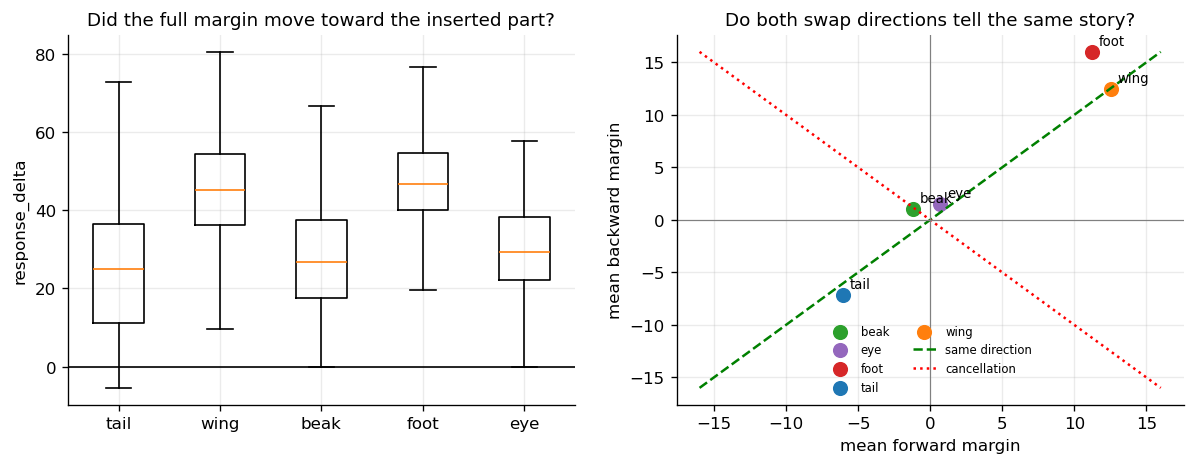

In [19]:
if S is not None:
    D=S.copy()
    if "response_delta" not in D:
        D["response_delta"]=D.margin-(D.z_new_orig-D.z_old_orig)
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    vals=[D[D.part==p].response_delta.dropna().values for p in ORDER]
    axes[0].boxplot(vals,labels=ORDER,showfliers=False)
    axes[0].axhline(0,color="black",linewidth=1)
    axes[0].set_ylabel("response_delta")
    axes[0].set_title("Did the full margin move toward the inserted part?")

    M=(D.groupby(["part","direction"]).margin.mean()
         .unstack("direction").dropna())
    colors={p:c for p,c in zip(ORDER,plt.cm.tab10.colors)}
    for p,r in M.iterrows():
        axes[1].scatter(r["fwd"],r["bwd"],s=65,color=colors[p],label=p)
        axes[1].annotate(p,(r["fwd"],r["bwd"]),xytext=(4,4),
                         textcoords="offset points",fontsize=8)
    lim=max(abs(M[["fwd","bwd"]].values).max(),1)
    axes[1].plot([-lim,lim],[-lim,lim],"--",color="green",
                 label="same direction")
    axes[1].plot([-lim,lim],[lim,-lim],":",color="red",
                 label="cancellation")
    axes[1].axhline(0,color="gray",linewidth=.7)
    axes[1].axvline(0,color="gray",linewidth=.7)
    axes[1].set_xlabel("mean forward margin")
    axes[1].set_ylabel("mean backward margin")
    axes[1].set_title("Do both swap directions tell the same story?")
    axes[1].legend(fontsize=7,ncol=2)


**Interpretation rule.** Positive `response_delta` means the inserted
pixels influenced the correct comparison. A negative final margin means that
movement was still insufficient to overcome the old source-associated preference.
Forward/backward points near the positive diagonal rule out cancellation as the
reason for the average.

The second backport completes the species test. Raw source-species failure can
merely restate source-tail variant because every species has one canonical tail.
Subtract each source variant's mean failure rate before asking whether species
differences remain.


,sid_src,var_src,violation,variant_mean,within_variant_residual
43,43,2,1.000,0.639,0.361
23,23,5,1.000,0.673,0.327
4,4,1,0.840,0.576,0.264
14,14,6,0.900,0.646,0.254
7,7,0,0.833,0.592,0.242
27,27,3,1.000,0.773,0.227
34,34,2,0.857,0.639,0.218
35,35,2,0.850,0.639,0.211
28,28,0,0.800,0.592,0.208
24,24,3,0.943,0.773,0.170


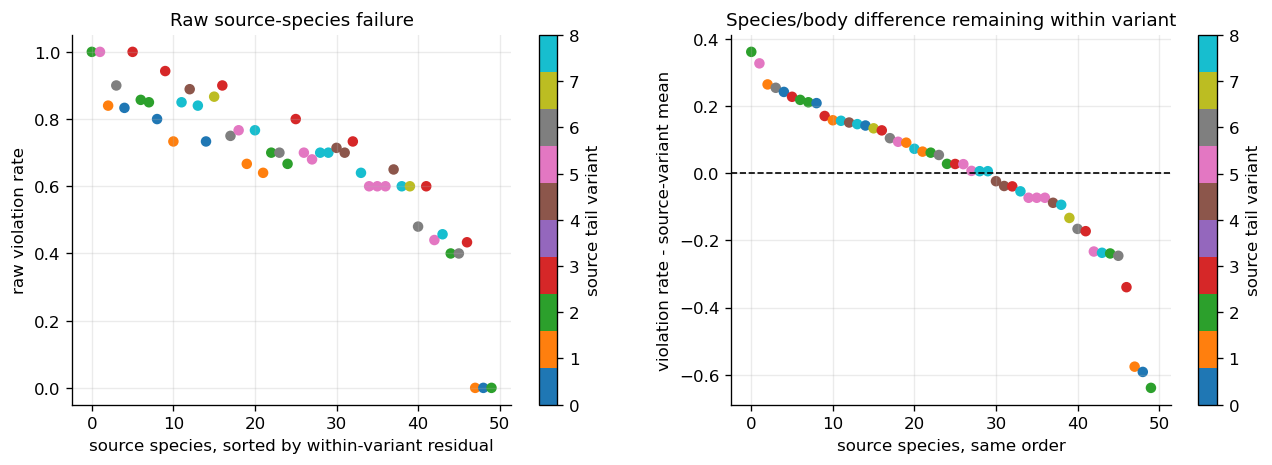

In [20]:
if S is not None and {"sid_src","var_src"}.issubset(S.columns):
    t=S[S.part=="tail"].copy()
    raw=(t.assign(violation=~t.ordering_correct.astype(bool))
          .groupby(["sid_src","var_src"]).violation.mean().reset_index())
    raw["variant_mean"]=raw.groupby("var_src").violation.transform("mean")
    raw["within_variant_residual"]=raw.violation-raw.variant_mean
    raw=raw.sort_values("within_variant_residual",ascending=False)
    fig,axes=plt.subplots(1,2,figsize=(13,4))
    sc=axes[0].scatter(range(len(raw)),raw.violation,
                       c=raw.var_src,cmap="tab10",s=28)
    axes[0].set_xlabel("source species, sorted by within-variant residual")
    axes[0].set_ylabel("raw violation rate")
    axes[0].set_title("Raw source-species failure")
    fig.colorbar(sc,ax=axes[0],label="source tail variant")
    sc2=axes[1].scatter(range(len(raw)),raw.within_variant_residual,
                        c=raw.var_src,cmap="tab10",s=28)
    axes[1].axhline(0,color="black",linestyle="--",linewidth=1)
    axes[1].set_xlabel("source species, same order")
    axes[1].set_ylabel("violation rate - source-variant mean")
    axes[1].set_title("Species/body difference remaining within variant")
    fig.colorbar(sc2,ax=axes[1],label="source tail variant")
    display(raw.head(15).round(3))


**Limited conclusion.** Residual spread supports an additional
source-body/species association beyond source-tail variant. It remains
observational because the body itself was not independently swapped.

### Updated CBM evidence chain

1. The CBM is accurate and appears grounded on ordinary images.
2. Controlled swaps reveal a graded problem: tail is worst, while beak and eye
   are also imperfect; wing and foot are stronger controls.
3. `response_delta` asks whether inserted pixels moved the complete
   donor-versus-source comparison. Positive movement with a negative final margin
   means “the model saw the part, but the old context remained stronger.”
4. Visibility is tested next and is only a partial explanation.
5. Variant confusion and donor-pair tests show unequal variants rather than one
   universally broken slot.
6. Within-variant residuals test whether source body/species still matters after
   accounting for canonical variant.
7. The complete concept vector identifies the species-associated concept
   combination, but this is not by itself extra within-concept leakage;
   downstream species-probability effects are modest.
8. Notebook 03 then asks whether minimality removes this grounding problem.


## 11 · What is established, and what would settle the mechanism?

Established by the current CBM runs:

1. Ordinary concept predictions are highly accurate.
2. Controlled replacements reveal part-specific grounding failure.
3. Tail donors usually move `z_donor` but often fail to overcome `z_source`.
4. Test-time visibility and variant combination explain part of the tail failure, not all.
5. Wing and foot are grounded positive controls.

Not yet uniquely established: that the residual tail answer is computed from species/body pixels.

The decisive functional test is a two-factor renderer experiment:

`z_tail = f(tail identity T, body/species B)`.

Independently vary `T` and `B`. The intended effect is large change with `T` while `B` is fixed. Backwash is directly demonstrated when changing only `B` changes `z_tail` while the exact tail is fixed. The reverse spillover test changes only `T` and checks non-tail outputs `z_beak`, `z_wing`, `z_eye`, and `z_foot`.

A visibility-aware retrained CBM then tests cause: if reducing the label/pixel contradiction reduces the measured body effect, training-time occlusion was causal.

### Follow-up: visibility-aware relabeling

The training-label alternative is tested in **03rl · FunnyBirds visibility-aware labels**.
That notebook must be read after this discovery notebook, not as a replacement for it.

It first freezes the predictions made here:

- the removed source concept should turn off more strongly;
- donor-over-source ordering should improve most for tail, moderately for beak/eye, and
  little for foot/wing;
- deletion should leave less retained concept probability;
- variant and source-species structure may remain because relabeling does not change the
  number of variants or the body/species correlations.

It then evaluates standard and RLv2 checkpoints on identical validated renders, decomposes
donor and source score changes, repeats visibility and all-part variant controls, tests
source-species residuals after matching variant/direction/visibility, and selects actual
unexplained examples for visual inspection. The current seed-1 result is provisional until
seeds 2–3 and the independent RLv2 deletion run are complete.


## Provenance

The intervention, direction check, confusion matrix, species breakdown, downstream response, and visibility ideas come from the complete original renderer notebooks. They are reordered here so every result motivates the next question. Rendering and model-loading run in the SLURM driver; the notebook reads saved results.
